# Info
Work through the lessons hands-on
  Copy/paste the provided code, run step-by-step, and after each output/plot add one sentence explaining what changed and why.

Do the exercises before opening solutions
Try first, then compare to the provided solution notebooks. Note differences and what you learned.

Build small utility cells you’ll reuse
Keep helpers for parsing dates, resampling, rolling metrics, etc.


In [267]:
# --- Imports & defaults ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

from sklearn.metrics import mean_absolute_error
from pandas.tseries.frequencies import to_offset

# Getting Started with Dates and Times in Pandas

In [268]:
## Creating a Time-Aware DataFrame

In [269]:
# 2. 🏗️ Creating a Time-Aware DataFrame
# You often start with a sequence of dates; assigning these as your DataFrame’s index makes all subsequent operations time-aware (slicing, plotting, resampling).

import pandas as pd
# Generate 5 daily timestamps
dates = pd.date_range(start='2023-01-01', periods=5, freq='D')

# Create a DataFrame indexed by these dates
df = pd.DataFrame({'value': [10, 20, 15, 25, 30]}, index=dates)
print(df)

            value
2023-01-01     10
2023-01-02     20
2023-01-03     15
2023-01-04     25
2023-01-05     30


In [270]:
# 3. ⏱️ Timestamps: Representing a Single Point
# A Timestamp behaves like a Python datetime, but with extra Pandas methods.

ts = pd.Timestamp('2023-07-01')
print(ts)

2023-07-01 00:00:00


In [271]:
# 4. 🔍 Accessing Time Components
# Once you have a Timestamp, you can pull out parts of it (year, month, weekday) to drive features or filters.


print(ts.year)        # 2023
print(ts.month)       # 7
print(ts.day_name())  # 'Saturday'

2023
7
Saturday


In [272]:
# 5. 📆 Periods: Representing Time Spans
# A Period bundles all instants within a span (month, quarter). Great for period-based analyses.


p = pd.Period('2023-07', freq='M')
print(p)                       # 2023-07
print(p.to_timestamp(how='end'))  # 2023-07-31 23:59:59.999999999


2023-07
2023-07-31 23:59:59.999999999


In [273]:
# 6. ➕ Doing Arithmetic with Dates & Periods
# Shift periods or timestamps by calendar increments.


from pandas.tseries.offsets import DateOffset, MonthEnd

# Period arithmetic: add 2 months
p_jan = pd.Period('2023-01', freq='M')
print(p_jan + 2)         # 2023-03

# Timestamp arithmetic: roll forward to next month end
ts = pd.Timestamp('2023-01-31')
print(ts + MonthEnd(1))  # 2023-02-28 00:00:00
print(ts + DateOffset(months=2))  # 2023-03-31 00:00:00

2023-03
2023-02-28 00:00:00
2023-03-31 00:00:00


In [274]:
# 7. 🧭 Creating Sequences of Dates
# Fill out a full calendar of dates with date_range or a full set of periods with period_range.

# Daily timestamps
daily = pd.date_range('2023-01-01', periods=5, freq='D')
print(daily)

# Monthly periods
periods = pd.period_range('2023-01', periods=5, freq='M')
print(periods)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05'],
              dtype='datetime64[ns]', freq='D')
PeriodIndex(['2023-01', '2023-02', '2023-03', '2023-04', '2023-05'], dtype='period[M]')


In [275]:
# 8. 🔄 Switching to a PeriodIndex
# Explanation: Convert a DatetimeIndex to a PeriodIndex when you want period-based operations.

dt_idx = pd.date_range('2023-01-01', periods=5, freq='D')
pr_idx = dt_idx.to_period('D')
print(pr_idx)

PeriodIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
             '2023-01-05'],
            dtype='period[D]')


In [276]:
# 9. 🛠️ Creating a Time Series DataFrame
# Combine date sequences and data arrays into a cohesive time series table.

import numpy as np

dates = pd.date_range('2023-01-01', periods=5, freq='D')
df_ts = pd.DataFrame(
    {'A': range(5), 'B': np.random.randn(5)},
     index=dates
)
print(df_ts)

            A         B
2023-01-01  0  1.303407
2023-01-02  1  0.303758
2023-01-03  2  1.951711
2023-01-04  3 -0.472657
2023-01-05  4 -0.116097


10. ⚙️ Understanding Frequency Aliases
Alias	Meaning	Example use
D	Daily	date_range(..., freq='D')
B	Business day	freq='B'
H	Hourly	freq='H'
M	Month-end	freq='M'
MS	Month-start	freq='MS'
Q	Quarter-end	freq='Q'
A	Year-end	freq='A'
Tip: Use uppercase for calendar; lowercases like h, d also work but are less common.

🧪 Exercise: Hands-On with Dates, Timestamps & Periods in Pandas
In this exercise, you’ll put into practice all of the core datetime skills from this lesson: converting raw strings, building time-aware DataFrames, exploring Timestamp and Period objects, performing calendar arithmetic, generating date/period sequences, and working with frequency aliases.


In [277]:
# ⚙️ Setup
import pandas as pd
import numpy as np
from pandas.tseries.offsets import MonthEnd, DateOffset

# Provided data
date_strings = [
    '2023-01-01', '2023-01-02', '2023-01-03',
    '2023-01-04', '2023-01-05'
]
values = [10, 20, 15, 25, 30]

- Convert & Index
- Convert date_strings to datetime64 using pd.to_datetime().
- Build a DataFrame df with values and set the converted dates as its index.


In [278]:
datetime64= pd.to_datetime(date_strings)

df_exercise = pd.DataFrame({'value': values}, index=datetime64)
print(df_exercise)

            value
2023-01-01     10
2023-01-02     20
2023-01-03     15
2023-01-04     25
2023-01-05     30


- Extract Timestamp Attributes
- From the first index entry in df, extract the year, month, and day name.
- Add these as new columns (year, month, weekday) in df.

In [279]:
df['year'] = df.index.year
df['month'] = df.index.month
df['weekday'] = df.index.day_name()
print(df)

            value  year  month    weekday
2023-01-01     10  2023      1     Sunday
2023-01-02     20  2023      1     Monday
2023-01-03     15  2023      1    Tuesday
2023-01-04     25  2023      1  Wednesday
2023-01-05     30  2023      1   Thursday


- Create & Shift a Period
- Instantiate a monthly Period for January 2023.
- Add 2 months to that period, convert it to a Timestamp at the end of the period, and print the result.


In [280]:
p_jan = pd.Period('2023-01', freq='M')
shifted_period = p_jan + 2
result_timestamp = shifted_period.to_timestamp(how='end')
print(result_timestamp)

2023-03-31 23:59:59.999999999


In [281]:
p_jan = pd.Period('2023-03', freq='M')

shifted_period = p_jan + 2
print(shifted_period)   

result_timestamp = shifted_period.to_timestamp(how='end')               

print(result_timestamp)

2023-05
2023-05-31 23:59:59.999999999


- Shift a Timestamp
- Take the last timestamp in your DataFrame and roll it forward one month-end using MonthEnd.
- Then roll it forward two months using DateOffset(months=2).

Timestamp arithmetic: roll forward to next month end
ts = pd.Timestamp('2023-01-31')
print(ts + MonthEnd(1))  # 2023-02-28 00:00:00
print(ts + DateOffset(months=2))  # 2023-03-31 00:00:00

In [282]:
print(result_timestamp + MonthEnd(1))

print(result_timestamp + DateOffset(months=3, day=12))

2023-06-30 23:59:59.999999999
2023-08-12 23:59:59.999999999


- Generate Date & Period Sequences
- Create a daily DatetimeIndex from 2023-02-01 for 7 days.
- Create a monthly PeriodIndex starting 2023-02 for 6 periods.

7. 🧭 Creating Sequences of Dates
 Fill out a full calendar of dates with date_range or a full set of periods with period_range.

 Daily timestamps
daily = pd.date_range('2023-01-01', periods=5, freq='D')
print(daily)

 Monthly periods
periods = pd.period_range('2023-01', periods=5, freq='M')
print(periods)

In [283]:
daily= pd.date_range('2023-02-01', periods=7, freq='D')
print(daily)

DatetimeIndex(['2023-02-01', '2023-02-02', '2023-02-03', '2023-02-04',
               '2023-02-05', '2023-02-06', '2023-02-07'],
              dtype='datetime64[ns]', freq='D')


In [284]:
monthly= pd.period_range('2023-01', periods=6, freq='M')
print(monthly)

PeriodIndex(['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06'], dtype='period[M]')


- Convert to PeriodIndex
- Convert the daily DatetimeIndex you just made into a PeriodIndex with daily frequency.

dt_idx = pd.date_range('2023-01-01', periods=5, freq='D')
pr_idx = dt_idx.to_period('D')
print(pr_idx)

In [285]:
dt_daily= pd.date_range('2023-01-01', periods=5, freq='D')
pr_daily= dt_daily.to_period('D')
print(pr_daily)

PeriodIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
             '2023-01-05'],
            dtype='period[D]')


Build a Time Series DataFrame
Using your monthly DatetimeIndex, create a new DataFrame df2 with two columns:
A as the sequence 0,1,2,3,4,5
B as 6 random normal values (np.random.randn(6))

dates = pd.date_range('2023-01-01', periods=5, freq='D')
df_ts = pd.DataFrame(
    {'A': range(5), 'B': np.random.randn(5)},
     index=dates
)
print(df_ts)

In [286]:
df2= pd.DataFrame({'A': range(6), 'B': np.random.randn(6)}, index=monthly)
print(df2)

         A         B
2023-01  0  0.550982
2023-02  1  0.134886
2023-03  2 -2.402567
2023-04  3 -1.684979
2023-05  4 -0.766200
2023-06  5 -1.418661


Use Frequency Aliases
Generate a DatetimeIndex of business days for March 2023 using the alias 'B'.

In [287]:
business_days = pd.date_range('2023-03-01', '2023-03-31', freq='B')
print(business_days)

DatetimeIndex(['2023-03-01', '2023-03-02', '2023-03-03', '2023-03-06',
               '2023-03-07', '2023-03-08', '2023-03-09', '2023-03-10',
               '2023-03-13', '2023-03-14', '2023-03-15', '2023-03-16',
               '2023-03-17', '2023-03-20', '2023-03-21', '2023-03-22',
               '2023-03-23', '2023-03-24', '2023-03-27', '2023-03-28',
               '2023-03-29', '2023-03-30', '2023-03-31'],
              dtype='datetime64[ns]', freq='B')


## 💡 Hints
Use df.index[0].year / .month / .day_name() for timestamp attributes.
For converting indices: pd.DatetimeIndex(...) and .to_period('D').
Frequency aliases: 'D', 'B', 'M', 'MS', etc

# Indexing & Transforming Real-World Time Series

## Learning

1. Convert raw date strings into datetime64.
2. Index your DataFrame by time.
3. Visualize a time series.
4. Slice and dice by date strings.
5. Change the frequency of your series (upsampling & downsampling).
6. Identify and handle missing observations introduced by frequency changes.

1. Indexing & Resampling Time Series
Concept:
A time series becomes powerful when you set its index to be a DatetimeIndex. Once indexed, you can resample (e.g. daily→monthly mean) and aggregate by any calendar span.


2. Time Series Transformation
Concept:
Real-world CSVs often store dates as plain strings. Before indexing:
Parse them to datetime64
Set that column as the DataFrame index
Resample up or down to change granularity
Downsampling aggregates (e.g. .mean(), .sum())
Upsampling creates new rows (gaps to fill)

In [288]:


import pandas as pd

# Load and parse dates in one step
goog = pd.read_csv(
    "goog_simulated.csv",              # local file after download
    parse_dates=["date"],
    index_col="date"
)

print(goog.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 523 entries, 2020-01-01 to 2021-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   close_price  523 non-null    float64
dtypes: float64(1)
memory usage: 8.2 KB
None


In [289]:
print(goog.info())
# Example: downsample daily data to monthly average
monthly = stock_data.resample('M').mean()
print(monthly)
# Example: upsample daily data to hourly (will introduce gaps)
hourly = stock_data.resample('H').asfreq()
print(hourly)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 523 entries, 2020-01-01 to 2021-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   close_price  523 non-null    float64
dtypes: float64(1)
memory usage: 8.2 KB
None
            close_price
date                   
2020-01-31  1539.622601
2020-02-29  1347.907929
2020-03-31  1238.912812
2020-04-30  1289.815519
2020-05-31  1255.817341
2020-06-30  1280.458982
2020-07-31  1249.295062
2020-08-31  1298.755298
2020-09-30  1421.633202
2020-10-31  1487.194677
2020-11-30  1606.953592
2020-12-31  1616.103770
2021-01-31  1502.416835
2021-02-28  1536.595077
2021-03-31  1721.085789
2021-04-30  1839.441702
2021-05-31  1751.761880
2021-06-30  1930.553906
2021-07-31  1957.178181
2021-08-31  2135.070109
2021-09-30  2065.777273
2021-10-31  1868.843598
2021-11-30  1935.055795
2021-12-31  1846.573643
                     close_price
date                            
2020-01-01 00:00

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2572234105.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = stock_data.resample('M').mean()
/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2572234105.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = stock_data.resample('H').asfreq()


6. Plotting the Google Stock Time Series
import matplotlib.pyplot as plt



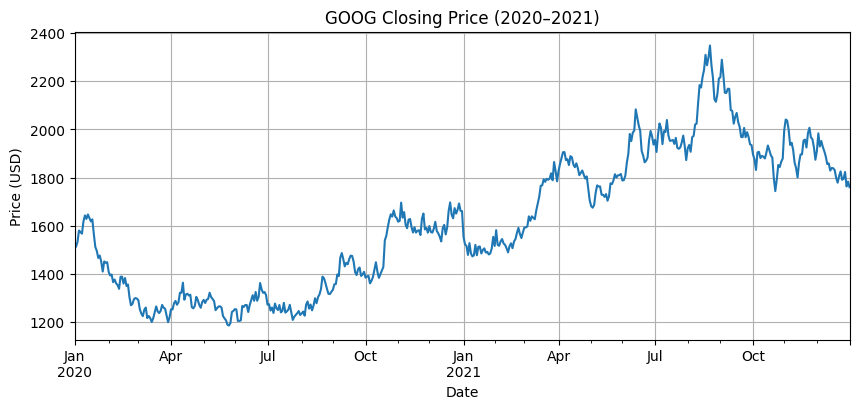

In [290]:
goog["close_price"].plot(
    title="GOOG Closing Price (2020–2021)",
    figsize=(10, 4)
)
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

7. Partial String Indexing
When your DataFrame is indexed by dates, you can slice rows simply by using slice notation inside the square brackets.
🔍 Concept
df["start":"end"] tells Pandas: “Give me all rows whose index timestamps lie between start and end (inclusive).”
The strings start and end can be as coarse as a year ("2020"), a month ("2021-01"), or as precise as a day ("2021-01-15").
Don’t write df["2020"] (no colon) to get rows—Pandas will look for a column named "2020" and throw a KeyError.


In [291]:
# 🧑‍💻 Step-by-Step in Jupyter
# Inspect your time series
goog.head()

,close_price
date,
2020-01-01,1515.651425
2020-01-02,1512.218041
2020-01-03,1532.563075
2020-01-06,1580.012143
2020-01-07,1573.402846


In [292]:
# Slice an entire year
# All of 2020
goog_2020 = goog["2020":"2020"]
print(goog_2020.shape)
goog_2020.head()

(262, 1)


,close_price
date,
2020-01-01,1515.651425
2020-01-02,1512.218041
2020-01-03,1532.563075
2020-01-06,1580.012143
2020-01-07,1573.402846


In [293]:
# Slice a quarter
# Q1 2021 (Jan–Mar)
q1_2021 = goog["2021-01":"2021-03"]
print(q1_2021.shape)
q1_2021.head()

(64, 1)


,close_price
date,
2021-01-01,1553.764305
2021-01-04,1522.708048
2021-01-05,1515.777651
2021-01-06,1478.708303
2021-01-07,1527.724860


💡 Tips & Tricks
Year only: df["YYYY":"YYYY"]
Year–Month: df["YYYY-MM":"YYYY-MM"]
Full date: df["YYYY-MM-DD":"YYYY-MM-DD"]
Supports inclusive slicing—the end date is included in the result.
Use this quick syntax whenever you need to pull out a calendar-aligned window without extra code.

8. Using .loc[] with Dates
Once your DataFrame is time-indexed, you can use the .loc[] accessor to select both rows (by date) and columns in one go.
🔍 Concept
df.loc[row_selector, col_selector] lets you specify:
row_selector: a single date, a date range, or a list of dates
col_selector: a column name, a list of names, or : for all columns
When you use a string or slice for row_selector on a DatetimeIndex, Pandas interprets it as date-based slicing.

In [294]:
# 🧑‍💻 Step-by-Step in Jupyter
# Closing price on January 15, 2021
goog.loc['2021-01-15', 'close_price']

np.float64(1512.576969308959)

In [295]:
# Select all columns for a single date
# All data on January 15, 2021 (returns a Series)
goog.loc['2021-01-15']

close_price    1512.576969
Name: 2021-01-15 00:00:00, dtype: float64

In [296]:
# Select a date range for one column
# Closing prices from Jan 1 to Jan 31, 2021
jan2021 = goog.loc['2021-01-01':'2021-01-31', 'close_price']
print(jan2021.shape)
jan2021.head()

(21,)


date
2021-01-01    1553.764305
2021-01-04    1522.708048
2021-01-05    1515.777651
2021-01-06    1478.708303
2021-01-07    1527.724860
Name: close_price, dtype: float64

In [297]:
# Select a date range and multiple columns
# (With a single-column DataFrame this returns a DataFrame anyway—here’s how it works if you had more columns.)
# Suppose you had columns ['open_price','close_price']
goog_sample = goog.copy()
goog_sample['open_price'] = goog_sample['close_price'] * 0.98  # dummy open

subset = goog_sample.loc['2021-06-01':'2021-06-15', ['open_price', 'close_price']]
subset.head()

,open_price,close_price
date,,
2021-06-01,1751.679972,1787.428543
2021-06-02,1753.414492,1789.198461
2021-06-03,1771.755148,1807.913416
2021-06-04,1824.062448,1861.288213
2021-06-07,1859.969877,1897.928446


💡 Tips & Tricks
Mix & match: combine precise row and column selections in one statement.
Slicing is inclusive of the end date.
Using .loc[] is the most explicit and versatile way to index time-based data when you need both rows and columns.

9. Using .asfreq() to Set Frequency
When you load a time series, its index may not carry explicit frequency information—even if the data are regularly spaced (e.g., every business day). The .asfreq() method lets you declare the frequency you expect, filling in any gaps with NaN.
🔍 Concept
df.asfreq(freq) returns a new Series/DataFrame having the specified frequency (freq) on its DatetimeIndex.
Upsampling (to a higher frequency) will introduce new timestamps with missing values.
Downsampling (to a lower frequency) will drop intermediate timestamps.


In [298]:
# 🧑‍💻 Example in Jupyter
# Assume goog has a DatetimeIndex of business days (freq='B')
# 1️⃣ Convert to a daily frequency (calendar days)
goog_daily = goog.asfreq('D')

# Inspect the first 10 rows
print(goog_daily.head(10))

# Check that Pandas now recognizes a daily frequency
print("Frequency attribute:", goog_daily.index.freq)

# Why? The original goog DataFrame only had entries for business days. By calling .asfreq('D'), 
# we told Pandas to expect a value every calendar day—so weekends appear with NaN.

            close_price
date                   
2020-01-01  1515.651425
2020-01-02  1512.218041
2020-01-03  1532.563075
2020-01-04          NaN
2020-01-05          NaN
2020-01-06  1580.012143
2020-01-07  1573.402846
2020-01-08  1566.821712
2020-01-09  1617.092022
2020-01-10  1642.720819
Frequency attribute: <Day>


In [299]:
# 🔄 Downsampling with .asfreq()
# You can also downsample by specifying a lower frequency:
# Keep only month-ends (drop all other days)

goog_monthly_end = goog_daily.asfreq('M')
goog_monthly_end.head()

# Result: Only the last calendar day of each month is retained; all other rows are dropped.
# Forward fill missing values
goog_monthly_end = goog_monthly_end.ffill()

goog_monthly_end.head()


/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2313864075.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  goog_monthly_end = goog_daily.asfreq('M')


,close_price
date,
2020-01-31,1448.515094
2020-02-29,1448.515094
2020-03-31,1219.677896
2020-04-30,1283.067523
2020-05-31,1283.067523


10. 📈 Upsampling Introduces Missing Values
When you increase the frequency of a time series—known as upsampling—Pandas will insert new timestamps at the higher frequency. Because your original data only had values at the lower frequency, all of these new timestamps will carry NaN until you explicitly fill or interpolate them.
📝 Explanation
Upsampling: expanding to a finer-grained time grid (e.g. daily → hourly)
Gaps: new timestamps appear where no original data existed
Detection: use .isna() or .isnull() to find these missing entries


In [300]:
# 🧑‍💻 Example in Jupyter
# Start with the business-day series
goog_biz = goog.asfreq('B')      # has values only on business days

# Upsample to hourly frequency
goog_hourly = goog_biz.asfreq('H')

# Inspect the first 10 rows
print(goog_hourly.head(10))
# Count how many hourly slots are missing
num_missing = goog_hourly['close_price'].isna().sum()
print("Missing hourly data points:", num_missing)

                     close_price
date                            
2020-01-01 00:00:00  1515.651425
2020-01-01 01:00:00          NaN
2020-01-01 02:00:00          NaN
2020-01-01 03:00:00          NaN
2020-01-01 04:00:00          NaN
2020-01-01 05:00:00          NaN
2020-01-01 06:00:00          NaN
2020-01-01 07:00:00          NaN
2020-01-01 08:00:00          NaN
2020-01-01 09:00:00          NaN
Missing hourly data points: 16998


/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/3757876725.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  goog_hourly = goog_biz.asfreq('H')


💡 Key Takeaways
Upsampling without filling will introduce NaN for all new timestamps.
Always inspect and fill or interpolate missing values (e.g., .ffill(), .bfill(), .interpolate()) before using upsampled data in models or visualizations.
Use missing-value detection (.isna(), .isnull()) to quantify gaps before proceeding.

11. 🏢 Switching to Business Day Frequency
When working with financial time series, you often want to align your data strictly to business days (i.e., Monday through Friday, excluding weekends and market holidays). Pandas lets you do this easily with the 'B' frequency alias in .asfreq().
🔍 Concept
Business-day frequency ('B'): includes only weekdays (Mon–Fri).
asfreq('B') on a daily-indexed series will drop weekend entries.
If your series wasn’t originally daily, it will add or remove rows to match the business-day calendar.


In [301]:
# 🧑‍💻 Step-by-Step in Jupyter
# Start from a daily series
# Suppose we’ve already made a daily series
goog_daily = goog.asfreq('D')
print("Original daily index sample:")
print(goog_daily.head(7))

# Convert to business-day frequency
goog_biz = goog_daily.asfreq('B')
print("After applying business-day freq:")
print(goog_biz.head(7))

#What changed?
#Entries for 2020-01-04 and 2020-01-05 (weekend) have been removed.
#The index now only contains business days, matching typical trading calendars.


Original daily index sample:
            close_price
date                   
2020-01-01  1515.651425
2020-01-02  1512.218041
2020-01-03  1532.563075
2020-01-04          NaN
2020-01-05          NaN
2020-01-06  1580.012143
2020-01-07  1573.402846
After applying business-day freq:
            close_price
date                   
2020-01-01  1515.651425
2020-01-02  1512.218041
2020-01-03  1532.563075
2020-01-06  1580.012143
2020-01-07  1573.402846
2020-01-08  1566.821712
2020-01-09  1617.092022


💡 Key Takeaways
Use asfreq('B') to align your series to business days.
This automatically drops weekend rows (and any non-business days if you subsequently filter by holiday calendars).
Ensures your time series matches stock market schedules before analysis or modeling.

12. 🕵️ Identifying Missing Business Days
After aligning your series to a business-day calendar with .asfreq('B'), any dates on which trading didn’t occur (holidays, unexpected closures) will appear with NaN. Detecting these gaps is crucial before filling or interpolating your series.
🔍 Concept
Missing values in a business-day–indexed series indicate non-trading days such as market holidays.
Use boolean indexing with .isna() (or .isnull()) to locate these dates.


In [302]:
# 🧑‍💻 Example in Jupyter
# Assume goog_biz is your business-day–indexed DataFrame
import pandas as pd

# Identify rows with missing close_price
missing_biz = goog_biz[goog_biz['close_price'].isna()]

# View the first few missing entries
print(missing_biz.head())
# How many business days have no trading data?
print("Number of missing business days:", missing_biz.shape[0])

Empty DataFrame
Columns: [close_price]
Index: []
Number of missing business days: 0


💡 Why This Matters
Holidays & Closures: Stock markets close on specific holidays—these will show as NaN if you align to all business days.
Data Integrity: Before resampling or modeling, decide how to handle these days (e.g., forward-fill last price, drop them, or interpolate).
Downstream Analysis: Ensures your metrics (returns, moving averages) aren’t skewed by unexpected gaps.
With this step, you’ve mastered how to detect and prepare for non-trading days in a business-day series.

## 🧪 Exercise: Structuring Time Series – Indexing & Visualizing Air Quality Trends
In this exercise, you’ll practice converting raw date strings into a time-aware DataFrame, slicing by dates, and visualizing multiple pollutants in subplots.
We’ll be using a simulated air quality dataset with daily readings for ozone, PM2.5, and CO spanning the year 2023. You can download it here:
📂 Download air_quality_trends_simulated.csv

In [303]:
# Load the dataset
import pandas as pd
df = pd.read_csv("air_quality_trends_simulated.csv")

In [304]:
# Convert the date column to datetime and set it as the index:
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

In [305]:
# Inspect the DataFrame using .info() and .head() to confirm the index and dtypes.

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2023-01-01 to 2023-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ozone   365 non-null    float64
 1   pm25    365 non-null    float64
 2   co      365 non-null    float64
dtypes: float64(3)
memory usage: 11.4 KB


In [306]:
df.head()

,ozone,pm25,co
date,,,
2023-01-01,57.440675,18.758119,0.951169
2023-01-02,65.759468,26.725029,0.814028
2023-01-03,60.138169,16.970760,0.801403
2023-01-04,57.244159,32.121332,0.686995
2023-01-05,51.182740,25.700751,0.945567


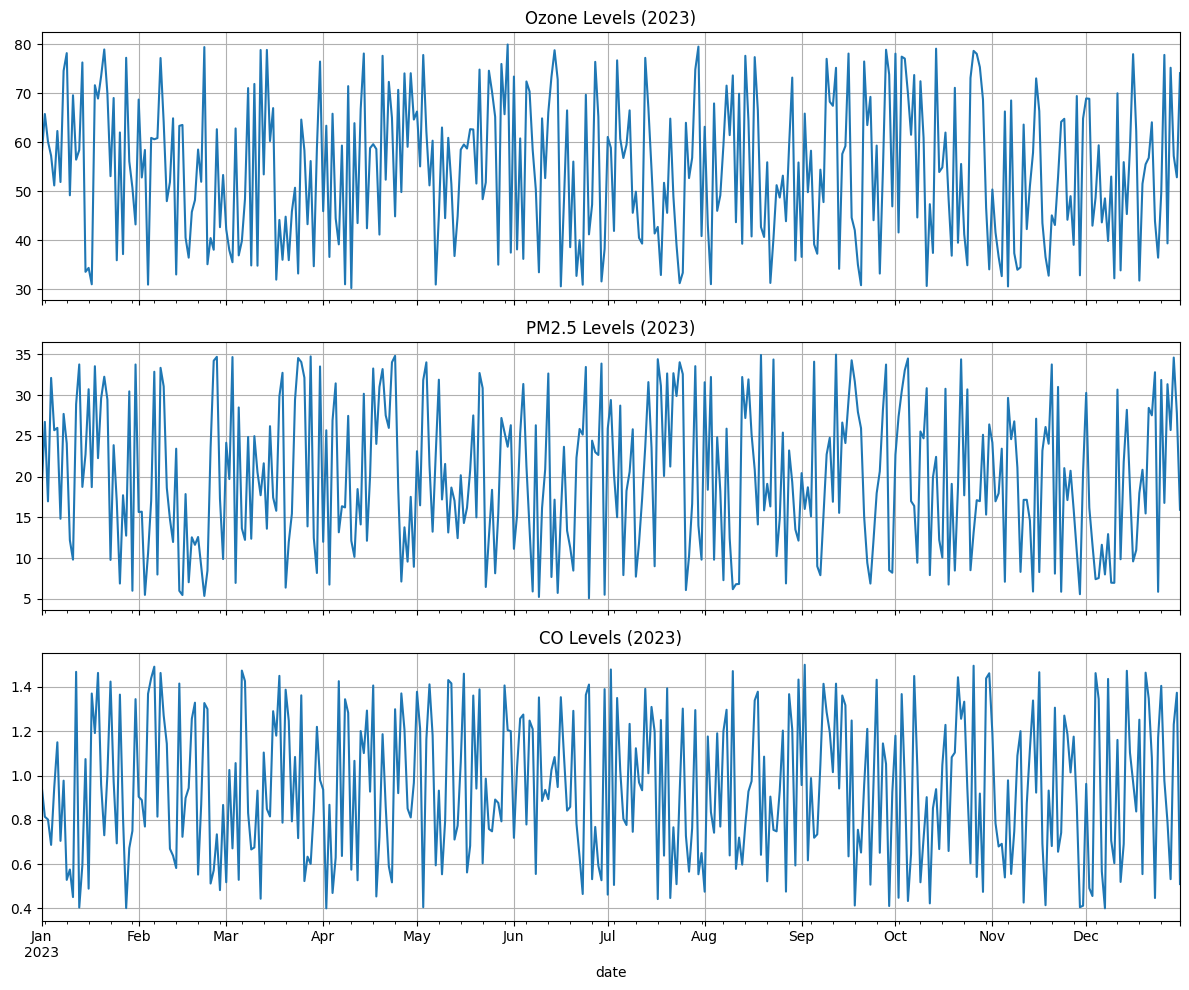

In [307]:
# Plot the full-year time series for each pollutant in separate subplots:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)
df["ozone"].plot(ax=axes[0], title="Ozone Levels (2023)")
df["pm25"].plot(ax=axes[1], title="PM2.5 Levels (2023)")
df["co"].plot(ax=axes[2], title="CO Levels (2023)")
plt.tight_layout()
plt.show()

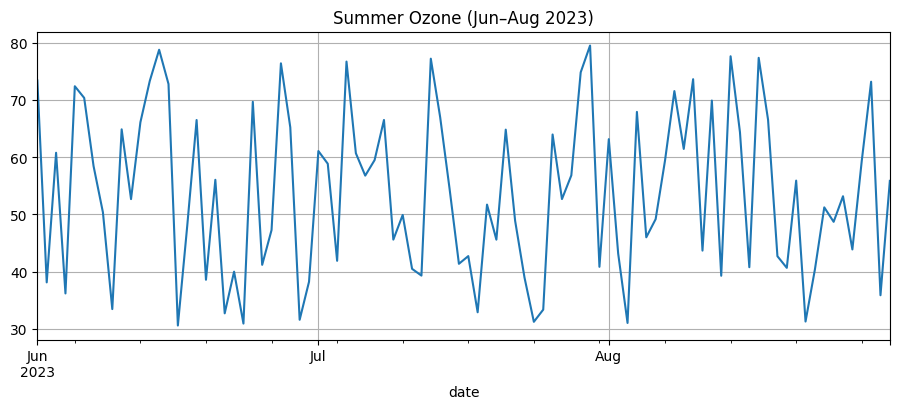

In [308]:
# Use partial string indexing (without .loc) to extract and plot the summer months (June–August 2023) for ozone only:

summer_ozone = df["2023-06":"2023-08"]["ozone"]
summer_ozone.plot(title="Summer Ozone (Jun–Aug 2023)")
plt.show()

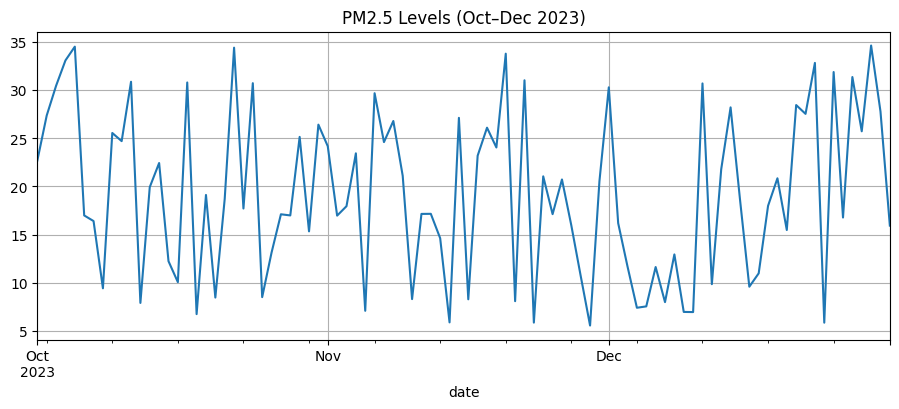

In [309]:
pm25_Q4 = df["2023-10":"2023-12"]["pm25"]
pm25_Q4.plot(title="PM2.5 Levels (Oct–Dec 2023)")
plt.show()

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/2236661454.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  co_monthly = df["co"].resample("M").mean()


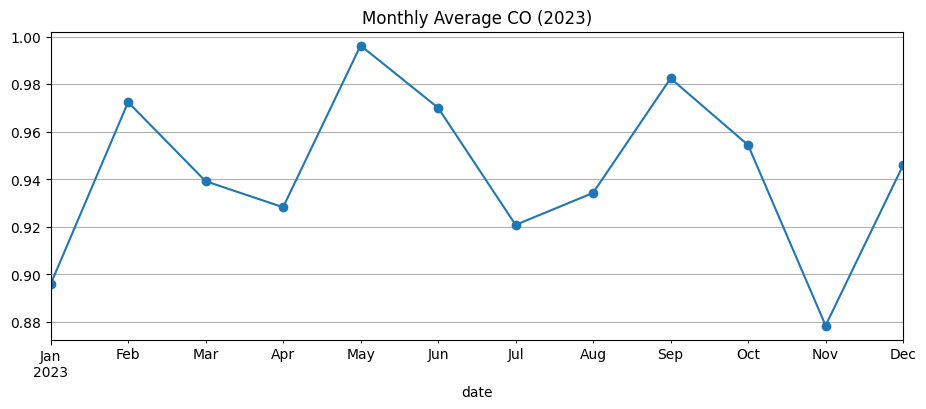

In [310]:
# Resample to monthly averages and plot the result for CO:
co_monthly = df["co"].resample("M").mean()
co_monthly.plot(marker="o", title="Monthly Average CO (2023)")
plt.show()

In [311]:
# Set a business-day frequency on the ozone series and count missing values (holidays):
oz_biz = df["ozone"].asfreq("B")
missing_holidays = oz_biz.isna().sum()
print("Missing business days in ozone data:", missing_holidays)

Missing business days in ozone data: 0


## 🧪 Exercise: Set and Change Time Series Frequency
In this exercise, you’ll practice declaring and transforming the observation frequency of a time-series DataFrame. You’ll work with the same simulated air quality dataset of daily readings for 2023, and:
Explicitly set a calendar-daily frequency
Upsample to hourly and fill in missing measurements
Downsample to monthly averages
Align to business-day frequency and identify gaps
📂 Dataset
Use the simulated air quality file: air_quality_trends_simulated.csv
(This contains daily ozone, pm25, and co for every day in 2023.)

In [312]:
# Load & Index
# Load the CSV into df with pd.read_csv().
# Convert "date" to datetime64 and set it as the index.


df = pd.read_csv("air_quality_trends_simulated.csv")

In [313]:
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

In [314]:
# Set Explicit Daily Frequency
# Use .asfreq('D') on df to declare a true calendar-daily series.
# Assign to df_daily.

df_daily = df.asfreq("D")

In [315]:
# Upsample to Hourly
# From df_daily, create df_hourly via .asfreq('H').
# Use .ffill() to forward-fill missing values at each hour.

df_hourly = df_daily.asfreq("h").ffill()

In [316]:
# Downsample to Monthly Means
# On df_daily, compute df_monthly = df_daily.resample('M').mean().
# This yields one row per month with average pollutant levels.

df_monthly = df_daily.resample("M").mean()

/var/folders/x7/81v83xkn2jl3b01w3b61s8tm0000gn/T/ipykernel_58896/938273563.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_daily.resample("M").mean()


In [317]:
# Align to Business-Day Frequency
# Apply .asfreq('B') on df_daily to get df_biz.
# Count how many business-day entries are NaN in the ozone column.

df_biz = df_daily.asfreq("B")
missing_biz_days = df_biz["ozone"].isna().sum()
print("Missing business days in ozone data:", missing_biz_days)

Missing business days in ozone data: 0


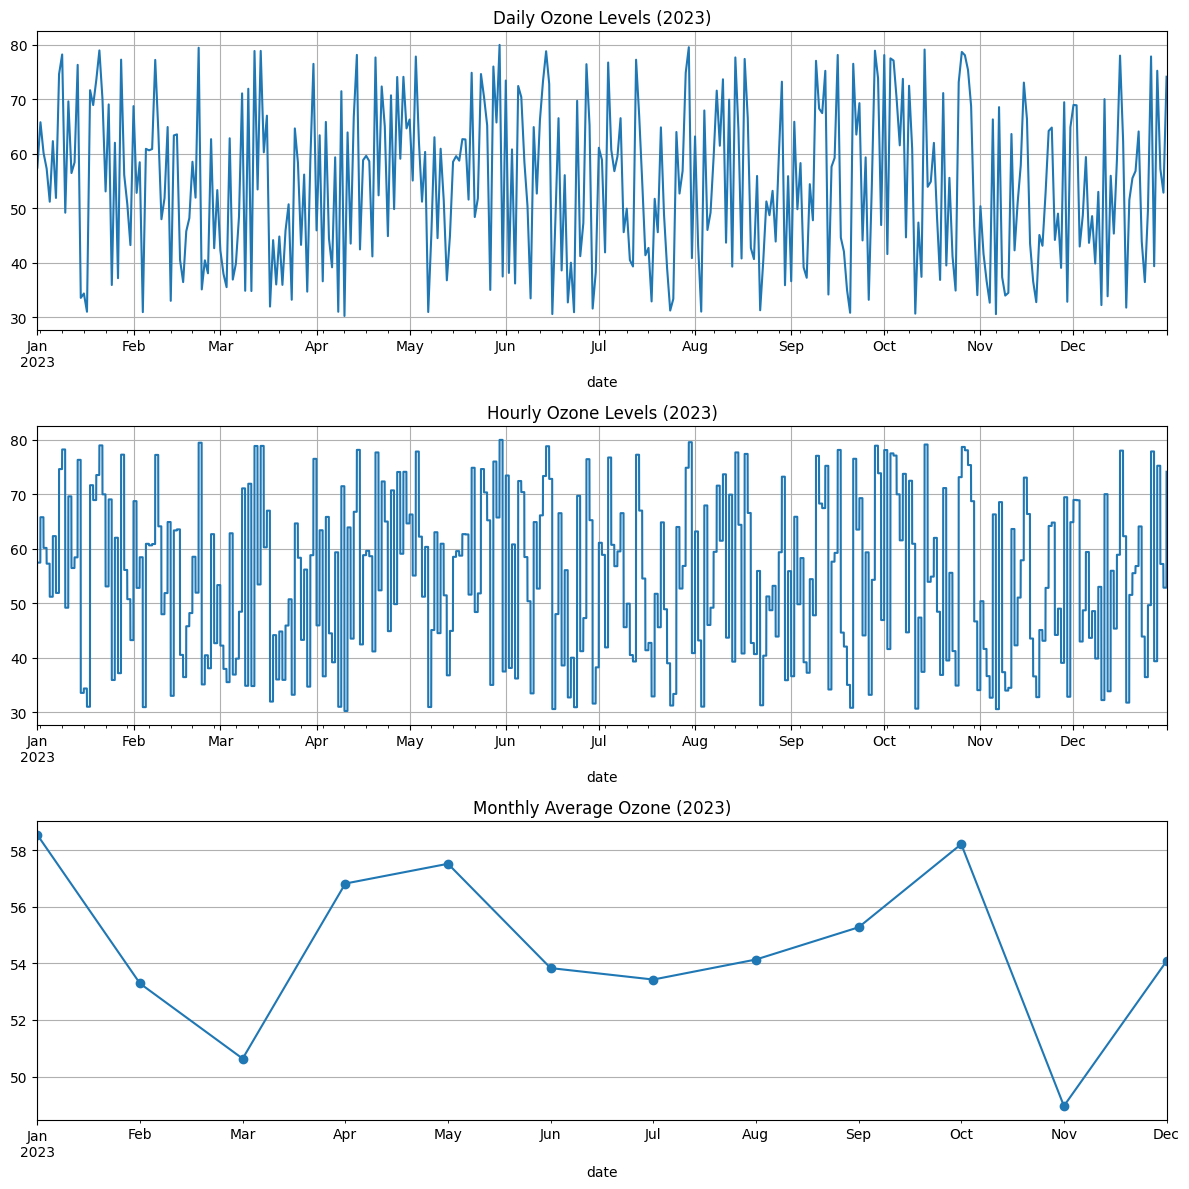

In [318]:
# Visualize the Results
# Plot three subplots (stacked vertically) in one figure:
# Daily series (df_daily["ozone"])
# Hourly series (df_hourly["ozone"])
# Monthly average (df_monthly["ozone"])

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12), sharex=False)
df_daily["ozone"].plot(ax=axes[0], title="Daily Ozone Levels (2023)")
df_hourly["ozone"].plot(ax=axes[1], title="Hourly Ozone Levels (2023)")
df_monthly["ozone"].plot(ax=axes[2], marker="o", title="Monthly Average Ozone (2023)")
plt.tight_layout()

# Lags, Changes, and Returns for Stock Price Series
1. Create lags and leads with .shift().
2. Compute absolute changes with .diff().
3. Compute simple returns (and log returns) — 1-period and multi-period.
4. Handle the NaN edges introduced by shifting.
5. Plot and sanity-check your transformations.